In [ ]:
# Neural Networks
# Video overview: https://developers.google.com/machine-learning/crash-course/introduction-to-neural-networks/video-lecture
# https://developers.google.com/machine-learning/crash-course/introduction-to-neural-networks/playground-exercises
# Tinker with networks: https://playground.tensorflow.org/
# A nice overview: https://www.cs.toronto.edu/~jlucas/teaching/csc411/lectures/tut5_handout.pdf
# Karpathy's blog: https://karpathy.github.io/neuralnets/
# Anil Jain's overview: https://csc.lsu.edu/~jianhua/nn.pdf
# Tech first book: https://www.oreilly.com/library/view/practical-machine-learning/9781098102357/

# (note to self 1,2,5)

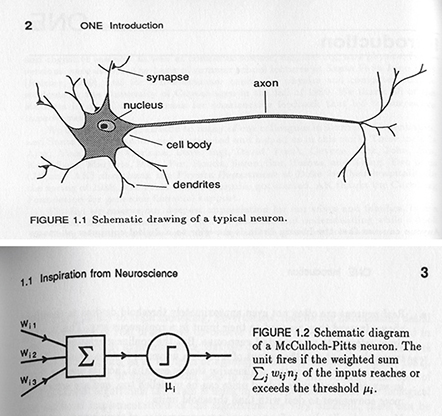

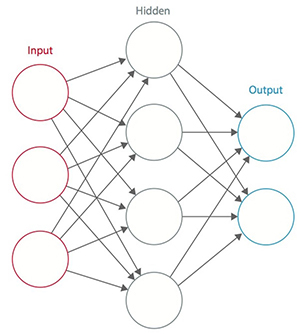

In [ ]:
# Back-Propagation Neural Networks
# based on Schemenauer's implementation
# details mb, nov 2010

In [1]:
# import libraries required for a  simple neural network
import math
import random
import string

In [5]:
# function definitions

# calculate a random number where:  a <= rand < b
def rand(a, b):
    return ((b-a)*random.random() + a)

# Make a matrix (we could use NumPy to speed this up)
def makeMatrix(I, J, fill=0.0):
    m = []
    for i in range(I):
        m.append([fill]*J)
    return (m)

# our sigmoid function, tanh is a little nicer than the standard 1/(1+e^-x)
def sigmoid(x):
    return (math.tanh(x))

# derivative of our sigmoid function
def dsigmoid(y):
    return (1.0-y*y)

class NN:
    def __init__(self, ni, nh, no):
        # number of input, hidden, and output nodes
        self.ni = ni + 1 # +1 for bias node
        self.nh = nh
        self.no = no

        # activations for nodes
        self.ai = [1.0]*self.ni
        self.ah = [1.0]*self.nh
        self.ao = [1.0]*self.no

        # create weights
        self.wi = makeMatrix(self.ni, self.nh)
        self.wo = makeMatrix(self.nh, self.no)
        # set them to random vaules
        for i in range(self.ni):
            for j in range(self.nh):
                self.wi[i][j] = rand(-2.0, 2.0)
        for j in range(self.nh):
            for k in range(self.no):
                self.wo[j][k] = rand(-2.0, 2.0)

        # last change in weights for momentum
        self.ci = makeMatrix(self.ni, self.nh)
        self.co = makeMatrix(self.nh, self.no)

    def update(self, inputs):
        if len(inputs) != self.ni-1:
            raise ValueError('wrong number of inputs')

        # input activations
        for i in range(self.ni-1):
            self.ai[i] = sigmoid(inputs[i])
            #self.ai[i] = inputs[i]

        # hidden activations
        for j in range(self.nh):
            sum = 0.0
            for i in range(self.ni):
                sum = sum + self.ai[i] * self.wi[i][j]
            self.ah[j] = sigmoid(sum)

        # output activations
        for k in range(self.no):
            sum = 0.0
            for j in range(self.nh):
                sum = sum + self.ah[j] * self.wo[j][k]
            self.ao[k] = sigmoid(sum)

        return (self.ao[:])


    def backPropagate(self, targets, N, M):
        if len(targets) != self.no:
            raise ValueError ('wrong number of target values')

        # calculate error terms for output
        output_deltas = [0.0] * self.no
        for k in range(self.no):
            error = targets[k]-self.ao[k]
            output_deltas[k] = dsigmoid(self.ao[k]) * error

        # calculate error terms for hidden
        hidden_deltas = [0.0] * self.nh
        for j in range(self.nh):
            error = 0.0
            for k in range(self.no):
                error = error + output_deltas[k]*self.wo[j][k]
            hidden_deltas[j] = dsigmoid(self.ah[j]) * error

        # update output weights
        for j in range(self.nh):
            for k in range(self.no):
                change = output_deltas[k]*self.ah[j]
                self.wo[j][k] = self.wo[j][k] + N*change + M*self.co[j][k]
                self.co[j][k] = change
                #print (N*change, M*self.co[j][k])

        # update input weights
        for i in range(self.ni):
            for j in range(self.nh):
                change = hidden_deltas[j]*self.ai[i]
                self.wi[i][j] = self.wi[i][j] + N*change + M*self.ci[i][j]
                self.ci[i][j] = change

        # calculate error
        error = 0.0
        for k in range(len(targets)):
            error = error + 0.5*(targets[k]-self.ao[k])**2
        return (error)


    def test(self, patterns):
        for p in patterns:
            print (p[0], '->', self.update(p[0]))

    def weights(self):
        print ('Input weights:')
        for i in range(self.ni):
            print (self.wi[i])
        print()
        print ('Output weights:')
        for j in range(self.nh):
            print (self.wo[j])

    def train(self, patterns, iterations=2000, N=0.8, M=0.1, EL = 0.01, INTV = 50):
        # N: learning rate  # M: momentum factor # EL: error limit #INTV: print interval
        error = 1
        i = 0
        while((error > EL) & (i < iterations)):
            i = i+1
            error = 0.0
            for p in patterns:
                inputs = p[0]
                targets = p[1]
                self.update(inputs)
                error = error + self.backPropagate(targets, N, M)
            #print every 50th iteration
            if i % INTV == 0:
                #print 'error %-14f' % error
                print('at iteration: %s -> error =  %s: ' % (i, error))

        print ("total number of iterations:", i)
        print ("final error:", error)

In [7]:
# main function
# do a random seed
random.seed(0)

# Create a pattern for the network
train_pat = [
[[0,0,0], [1]],
[[0,0,1], [0]],
[[0,1,0], [0]],
[[0,1,1], [0]],
[[1,0,0], [0]],
[[1,0,1], [0]],
[[1,1,0], [0]],
[[1,1,1], [1]]
            ]
# create a network with 3 inputs, 2 hidden layers, and one output node based
n = NN(3, 2, 1)
print ("training..")
n.train(train_pat)
print()

#test the network on a pattern
test_pat = [[[0,0,0.05]]]
print ("testing..")
n.test(test_pat)

training..
at iteration: 50 -> error =  0.8431982373229636: 
at iteration: 100 -> error =  0.22055561827935652: 
at iteration: 150 -> error =  0.11097238368526396: 
at iteration: 200 -> error =  0.07343547762777645: 
at iteration: 250 -> error =  0.05458911936747052: 
at iteration: 300 -> error =  0.04328620248603452: 
at iteration: 350 -> error =  0.03576294515479772: 
at iteration: 400 -> error =  0.030398683463256106: 
at iteration: 450 -> error =  0.026381666014123582: 
at iteration: 500 -> error =  0.023260760476472627: 
at iteration: 550 -> error =  0.020765392674745337: 
at iteration: 600 -> error =  0.01872351474192397: 
at iteration: 650 -> error =  0.017020540414441707: 
at iteration: 700 -> error =  0.015577222371973185: 
at iteration: 750 -> error =  0.01433701060937108: 
at iteration: 800 -> error =  0.013258470172129765: 
at iteration: 850 -> error =  0.012310545433217473: 
at iteration: 900 -> error =  0.011469498892191883: 
at iteration: 950 -> error =  0.01071687334490